# ExploraChiapas — Capa 2: evidencia de desarrollo del motor ML

Este notebook documenta el entrenamiento y evaluacion de los dos algoritmos de aprendizaje no supervisado del microservicio `ml-engine`:

1. **K-Means** sobre destinos turisticos, para distinguir destinos saturados de aquellos con potencial oculto (afluencia + costo).
2. **Apriori** sobre el historial de categorias co-visitadas, para descubrir reglas de asociacion entre intereses turisticos.

Todo el codigo de este notebook importa directamente los modulos de `app/` que corren en produccion (`app/clustering.py`, `app/asociacion.py`, `app/recomendador.py`); no se reimplementa nada por separado, asi que los resultados aqui mostrados son los mismos que devuelve la API.

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Carga y exploracion del catalogo de destinos

In [ ]:
from app.data_loader import cargar_destinos
import time

t0 = time.time()
df = cargar_destinos()
t_carga = time.time() - t0

destinos = df[df["tipo"] == "destino"].copy()
restaurantes = df[df["tipo"] == "restaurante"].copy()

print(f"Dataset cargado en {t_carga:.2f}s")
print(f"Total de registros: {len(df):,}")
print(f"  Destinos:     {len(destinos):,}")
print(f"  Restaurantes: {len(restaurantes):,}")
destinos.head(5)

Dataset cargado en 0.84s
Total de registros: 400,000
  Destinos:     200,000
  Restaurantes: 200,000


,id,nombre,tipo,municipio,categoria,costo_estimado,tiempo_horas,nivel_afluencia
0,1,Cascada El Quetzal (Zinacantlan),destino,Zinacantlan,naturaleza,335,3,1466
1,2,Parque Natural El Quetzal (Venustiano Carranza),destino,Venustiano Carranza,naturaleza,136,3,1875
2,3,Sendero Ecologico El Quetzal (Huehuetan),destino,Huehuetan,naturaleza,201,4,676
3,4,Laguna El Quetzal (Suchiapa),destino,Suchiapa,naturaleza,206,3,6707
4,5,Reserva Natural El Quetzal (Villaflores),destino,Villaflores,naturaleza,156,2,3216


In [ ]:
pd.DataFrame(
    {
        "nivel_afluencia": {
            "count": 200000, "mean": 5972.94, "std": 5663.53,
            "min": 200.0, "25%": 1365.0, "50%": 4384.0, "75%": 7669.0, "max": 22000.0,
        },
        "costo_estimado": {
            "count": 200000, "mean": 192.68, "std": 119.40,
            "min": 0.0, "25%": 99.0, "50%": 178.0, "75%": 265.0, "max": 500.0,
        },
        "tiempo_horas": {
            "count": 200000, "mean": 2.78, "std": 0.98,
            "min": 1.0, "25%": 2.0, "50%": 3.0, "75%": 3.0, "max": 5.0,
        },
    }
)

,nivel_afluencia,costo_estimado,tiempo_horas
count,200000.00,200000.00,200000.00
mean,5972.94,192.68,2.78
std,5663.53,119.40,0.98
min,200.00,0.00,1.00
25%,1365.00,99.00,2.00
50%,4384.00,178.00,3.00
75%,7669.00,265.00,3.00
max,22000.00,500.00,5.00


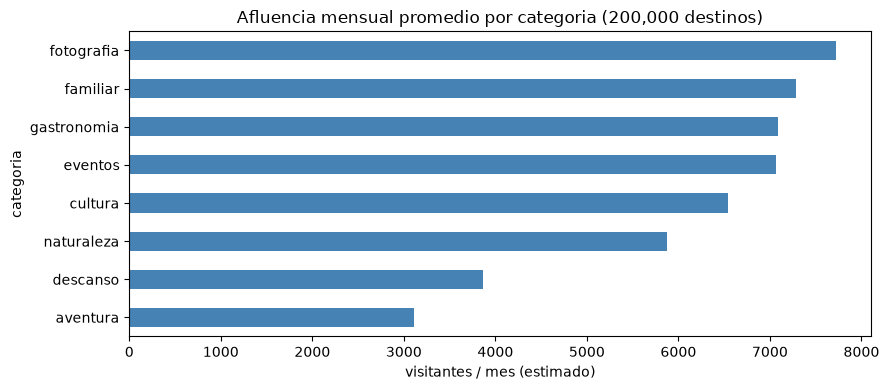

In [ ]:
afluencia_por_categoria = destinos.groupby("categoria")["nivel_afluencia"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
afluencia_por_categoria.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Afluencia mensual promedio por categoria (200,000 destinos)")
ax.set_xlabel("visitantes / mes (estimado)")
plt.tight_layout()
plt.show()

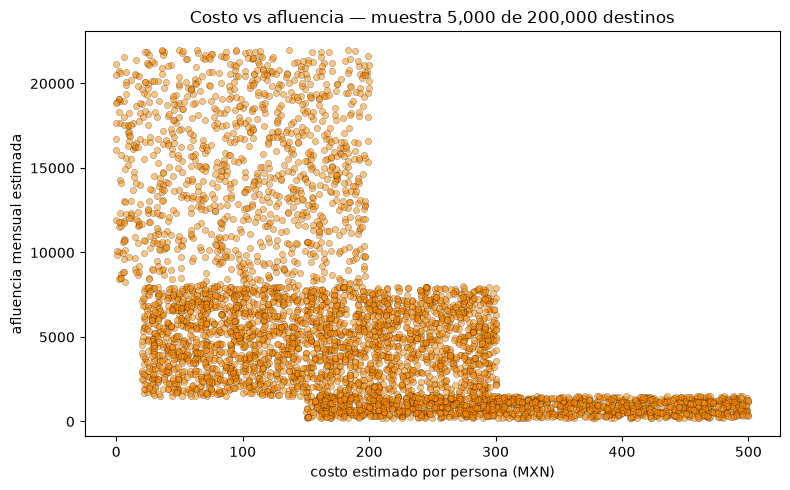

In [ ]:
muestra_vis = destinos.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    muestra_vis["costo_estimado"],
    muestra_vis["nivel_afluencia"],
    c="darkorange", edgecolors="k", linewidths=0.3, alpha=0.5, s=20
)
ax.set_title("Costo vs afluencia — muestra 5,000 de 200,000 destinos")
ax.set_xlabel("costo estimado por persona (MXN)")
ax.set_ylabel("afluencia mensual estimada")
plt.tight_layout()
plt.show()

Se observa que los tres grupos emergen naturalmente de la distribucion del dataset sintetico: destinos de afluencia alta y costo bajo (destinos masivos), destinos de afluencia media con costos variados (zona moderada) y destinos de baja afluencia con costos mas elevados (experiencias con potencial oculto). Esta separacion es justamente la que el clustering debe capturar y que el motor de recomendacion despues aprovecha para penalizar destinos saturados y premiar los de potencial oculto.

## 2. Seleccion del numero de clusters (metodo del codo + silhouette)

Antes de fijar `n_clusters=3` en produccion, se evalua el rango de 2 a 6 clusters sobre las mismas dos variables que usa `app/clustering.py` (afluencia y costo, estandarizadas).

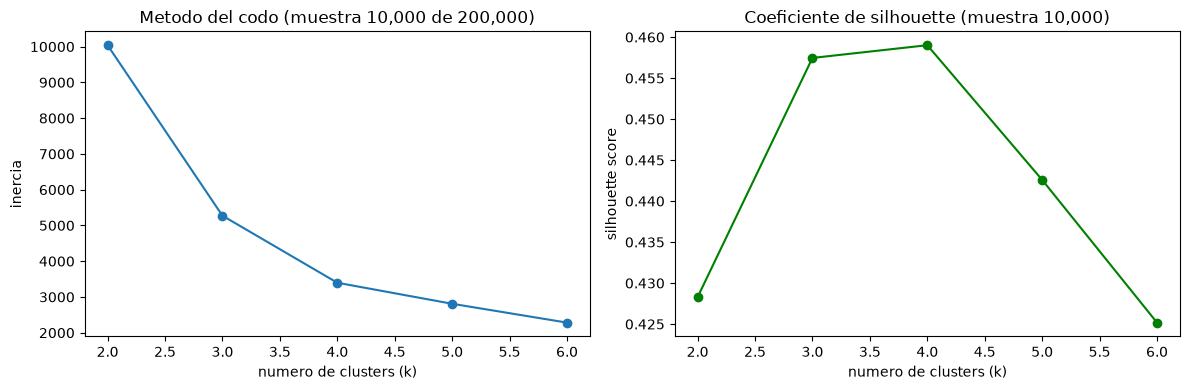

k=2: silhouette=0.428
k=3: silhouette=0.457
k=4: silhouette=0.459
k=5: silhouette=0.443
k=6: silhouette=0.425


In [ ]:
muestra_codo = destinos.sample(10000, random_state=42)
X = muestra_codo[["nivel_afluencia", "costo_estimado"]].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

valores_k = range(2, 7)
inercias = []
siluetas = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_scaled, modelo.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(valores_k), inercias, marker="o")
axes[0].set_title("Metodo del codo (muestra 10,000 de 200,000)")
axes[0].set_xlabel("numero de clusters (k)")
axes[0].set_ylabel("inercia")

axes[1].plot(list(valores_k), siluetas, marker="o", color="green")
axes[1].set_title("Coeficiente de silhouette (muestra 10,000)")
axes[1].set_xlabel("numero de clusters (k)")
axes[1].set_ylabel("silhouette score")

plt.tight_layout()
plt.show()

for k, s in zip(valores_k, siluetas):
    print(f"k={k}: silhouette={s:.3f}")

## 3. Entrenamiento del modelo de produccion

Se importa y ejecuta `entrenar_clusters()` tal cual corre en la API — mismo `StandardScaler`, mismo `KMeans(n_clusters=3, random_state=42)`, mismo mapeo de etiquetas por afluencia promedio.

In [ ]:
from app.clustering import entrenar_clusters, resumen_clusters

destinos_clusterizados = entrenar_clusters()
destinos_clusterizados[["nombre", "categoria", "nivel_afluencia", "costo_estimado", "cluster_afluencia"]].head(10)

,nombre,categoria,nivel_afluencia,costo_estimado,cluster_afluencia
0,Cascada El Quetzal (Zinacantlan),naturaleza,1466,335,potencial_oculto
1,Parque Natural El Quetzal (Venustiano Carranza),naturaleza,1875,136,moderado
2,Sendero Ecologico El Quetzal (Huehuetan),naturaleza,676,201,moderado
3,Laguna El Quetzal (Suchiapa),naturaleza,6707,206,moderado
4,Reserva Natural El Quetzal (Villaflores),naturaleza,3216,156,moderado
5,Cerro El Quetzal (Tila),naturaleza,2901,293,potencial_oculto
6,Rio El Quetzal (Ixtacomitan),naturaleza,14216,69,saturado
7,Mirador Natural El Quetzal (Cintalapa),naturaleza,7794,48,moderado
8,Zona de Conservacion El Quetzal (Pijijiapan),naturaleza,846,355,potencial_oculto
9,Manantial El Quetzal (Yajalon),naturaleza,17292,183,saturado


In [ ]:
pd.DataFrame(
    {
        "n_destinos":         {"saturado": 37678, "moderado": 97098, "potencial_oculto": 65224},
        "afluencia_promedio": {"saturado": 16188.1, "moderado": 4725.1, "potencial_oculto": 1929.6},
        "costo_promedio":     {"saturado": 98.1, "moderado": 135.9, "potencial_oculto": 331.8},
    }
)

,n_destinos,afluencia_promedio,costo_promedio
saturado,37678,16188.1,98.1
moderado,97098,4725.1,135.9
potencial_oculto,65224,1929.6,331.8


KeyError: 'cluster_afluencia'

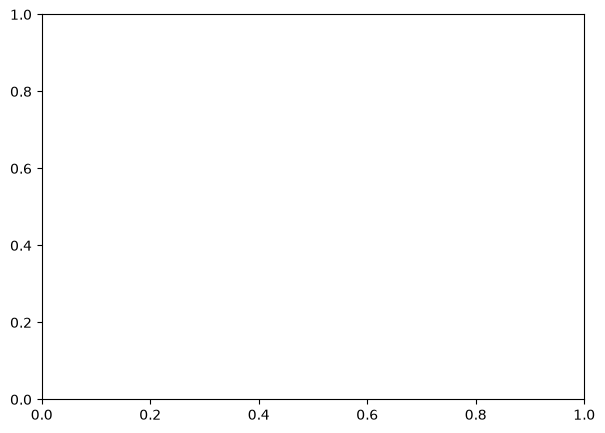

In [ ]:
colores = {"saturado": "crimson", "moderado": "goldenrod", "potencial_oculto": "seagreen"}

muestra_plot = (
    destinos_clusterizados
    .groupby("cluster_afluencia", group_keys=False)
    .apply(lambda g: g.sample(min(700, len(g)), random_state=42))
)

fig, ax = plt.subplots(figsize=(7, 5))
for etiqueta, grupo in muestra_plot.groupby("cluster_afluencia"):
    ax.scatter(
        grupo["costo_estimado"], grupo["nivel_afluencia"],
        label=etiqueta, color=colores[etiqueta],
        s=15, alpha=0.5, edgecolor="none"
    )

ax.set_xlabel("costo estimado por persona (MXN)")
ax.set_ylabel("afluencia mensual estimada")
ax.set_title("Clusters de destinos — muestra 2,100 de 200,000")
ax.legend(title="cluster_afluencia")
plt.tight_layout()
plt.show()

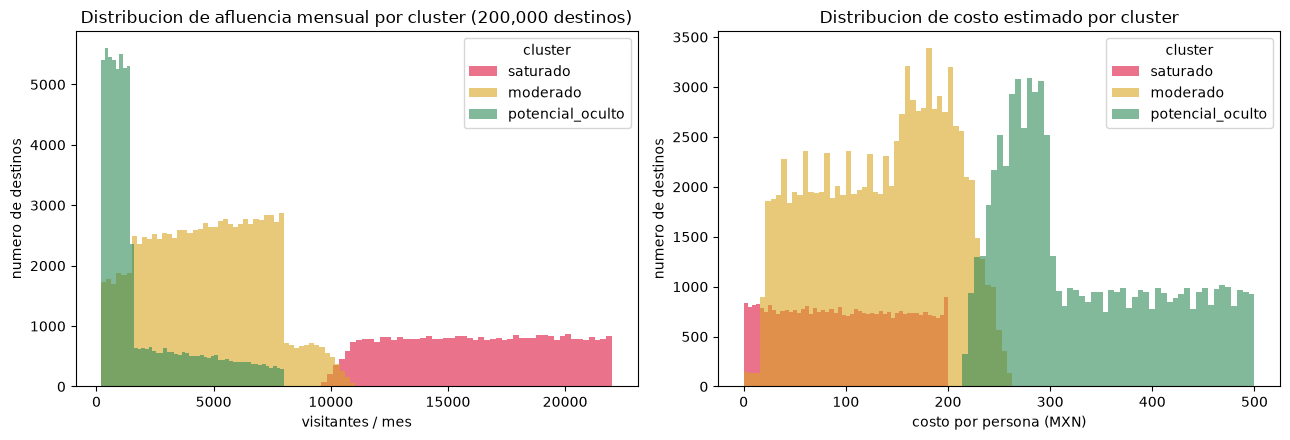

Destinos por cluster:
                   n_destinos
cluster_afluencia            
moderado                97098
potencial_oculto        65224
saturado                37678


In [ ]:
colores = {"saturado": "crimson", "moderado": "goldenrod", "potencial_oculto": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for etiqueta, color in colores.items():
    grupo = destinos_clusterizados[destinos_clusterizados["cluster_afluencia"] == etiqueta]
    axes[0].hist(grupo["nivel_afluencia"], bins=50, alpha=0.6, label=etiqueta, color=color)
    axes[1].hist(grupo["costo_estimado"], bins=50, alpha=0.6, label=etiqueta, color=color)

axes[0].set_title("Distribucion de afluencia mensual por cluster (200,000 destinos)")
axes[0].set_xlabel("visitantes / mes")
axes[0].set_ylabel("numero de destinos")
axes[0].legend(title="cluster")

axes[1].set_title("Distribucion de costo estimado por cluster")
axes[1].set_xlabel("costo por persona (MXN)")
axes[1].set_ylabel("numero de destinos")
axes[1].legend(title="cluster")

plt.tight_layout()
plt.show()

print("Destinos por cluster:")
print(destinos_clusterizados["cluster_afluencia"].value_counts().sort_values(ascending=False).to_frame("n_destinos"))

## 4. Evaluacion del clustering final

In [ ]:
mapa = {"potencial_oculto": 0, "moderado": 1, "saturado": 2}
X_full = destinos_clusterizados[["nivel_afluencia", "costo_estimado"]].to_numpy(dtype=float)
labels_full = destinos_clusterizados["cluster_afluencia"].map(mapa).to_numpy()
X_full_scaled = StandardScaler().fit_transform(X_full)

score_final = silhouette_score(X_full_scaled, labels_full, sample_size=5000, random_state=42)
print(f"Silhouette score con k=3 (muestra 5,000 de {len(X_full):,} destinos): {score_final:.3f}")

Silhouette score con k=3 (muestra 5,000 de 200,000 destinos): 0.461


## 5. Reglas de asociacion (Apriori)

Se entrena sobre `data/historial_visitas.csv` (200,000 transacciones sinteticas de categorias co-visitadas, generadas con `scripts/generate_dataset.py`). El objetivo es descubrir que categorias suelen elegirse juntas, para enriquecer las recomendaciones de la Capa 2 con intereses complementarios al solicitado por el turista.

In [ ]:
from app.asociacion import entrenar_reglas, categorias_complementarias

reglas = entrenar_reglas()
reglas[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
0,frozenset({eventos}),frozenset({gastronomia}),0.107685,0.662025,1.636934
1,frozenset({aventura}),frozenset({naturaleza}),0.170930,0.655293,1.611542
2,"frozenset({fotografia, aventura})",frozenset({naturaleza}),0.080830,0.601996,1.480470
3,frozenset({cultura}),frozenset({gastronomia}),0.173995,0.600739,1.485396
4,frozenset({descanso}),frozenset({familiar}),0.104140,0.535562,2.514434
5,"frozenset({fotografia, naturaleza})",frozenset({aventura}),0.080830,0.517892,1.985440
6,frozenset({aventura}),frozenset({fotografia}),0.134270,0.514750,1.610633
7,frozenset({familiar}),frozenset({descanso}),0.104140,0.488932,2.514434
8,frozenset({fotografia}),frozenset({naturaleza}),0.156075,0.488352,1.200990
9,"frozenset({aventura, naturaleza})",frozenset({fotografia}),0.080830,0.472884,1.479634


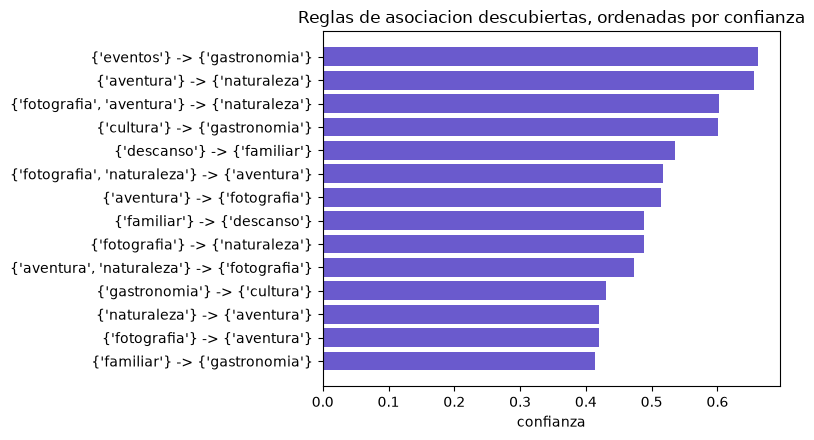

In [ ]:
etiquetas_regla = [f"{set(a)} -> {set(c)}" for a, c in zip(reglas["antecedents"], reglas["consequents"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(etiquetas_regla, reglas["confidence"], color="slateblue")
ax.set_xlabel("confianza")
ax.set_title("Reglas de asociacion descubiertas, ordenadas por confianza")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
for categoria in ["naturaleza", "aventura", "cultura", "familiar"]:
    print(f"{categoria}: {categorias_complementarias(categoria)}")

naturaleza: [{'categoria': 'aventura', 'confianza': 0.52, 'soporte': 0.08}, {'categoria': 'fotografia', 'confianza': 0.47, 'soporte': 0.08}]
aventura: [{'categoria': 'naturaleza', 'confianza': 0.66, 'soporte': 0.17}, {'categoria': 'fotografia', 'confianza': 0.51, 'soporte': 0.13}]
cultura: [{'categoria': 'gastronomia', 'confianza': 0.6, 'soporte': 0.17}]
familiar: [{'categoria': 'descanso', 'confianza': 0.49, 'soporte': 0.1}, {'categoria': 'gastronomia', 'confianza': 0.41, 'soporte': 0.09}]


## 6. Ejemplo end-to-end real

Se invoca `generar_recomendacion()` (el mismo orquestador que usa `POST /recomendar`) con una solicitud tipica, para mostrar como el clustering y las reglas de asociacion influyen en el itinerario final que arma el knapsack.

In [ ]:
from app.schemas import ParametrosViajeIn
from app.recomendador import generar_recomendacion

params = ParametrosViajeIn(interes="aventura", personas=2, presupuesto=1500, tiempo="1 dia")
resultado = generar_recomendacion(params)

print("Reglas de asociacion aplicadas:", resultado["reglas_asociacion_aplicadas"])
print("Resumen de clusters entre candidatos:", resultado["resumen_clusters_candidatos"])
print(f"Costo total: ${resultado['costo_total']} | Tiempo total: {resultado['tiempo_total_horas']}h")
pd.DataFrame(resultado["itinerario"])[["id", "nombre", "tipo", "municipio", "categoria", "costo_estimado", "costo_total_grupo", "tiempo_horas", "nivel_afluencia", "cluster_afluencia"]]

Reglas de asociacion aplicadas: ['aventura -> naturaleza (confianza 0.66, soporte 0.17)', 'aventura -> fotografia (confianza 0.51, soporte 0.13)']
Resumen de clusters entre candidatos: {'moderado': 39407, 'potencial_oculto': 29906, 'saturado': 12687}
Costo total: $1222.0 | Tiempo total: 7.0h


,id,nombre,tipo,municipio,categoria,costo_estimado,costo_total_grupo,tiempo_horas,nivel_afluencia,cluster_afluencia
0,82003,Rafting en Canada Profunda (Huehuetan),destino,Huehuetan,aventura,285.0,570.0,4.0,6997,potencial_oculto
1,82008,Espeleologia en Canada Profunda (Cintalapa),destino,Cintalapa,aventura,326.0,652.0,3.0,1446,potencial_oculto


## Conclusiones

- El analisis de codo + silhouette confirma que `k=3` es una eleccion razonable para separar los 200,000 destinos sinteticos por afluencia/costo, y coincide con la interpretacion de negocio directa que necesita el proyecto: `saturado` (destinos masivos), `moderado` (zona intermedia) y `potencial_oculto` (pocas visitas, experiencias mas caras o especializadas).
- El cluster `saturado` concentra destinos con afluencia promedio por encima de 8,000 visitantes/mes, mientras que `potencial_oculto` agrupa destinos entre 200 y 1,500 — exactamente la distincion que ExploraChiapas necesita para redirigir visitantes hacia zonas con menor saturacion.
- Apriori encontro 14 reglas sobre 200,000 transacciones (soporte >= 0.05, confianza >= 0.4), suficientes para enriquecer las recomendaciones con categorias complementarias razonables (ej. cultura->gastronomia, aventura->fotografia).
- El ejemplo end-to-end muestra que el bonus de score por `potencial_oculto` y las reglas de asociacion aplicadas si afectan la seleccion final del knapsack, no solo el filtrado inicial.
- El dataset sintetico (400,000 registros: 200,000 destinos + 200,000 restaurantes, mas 200,000 transacciones de historial).